In [2]:
# Install required packages
!pip install pandas matplotlib seaborn nltk wordcloud

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from wordcloud import WordCloud
from nltk.util import ngrams

# Download NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('averaged_perceptron_tagger')  # CHANGED: Already included, but keeping for clarity
nltk.download('averaged_perceptron_tagger_eng')  # NEW: Added to fix LookupError

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


Mounted at /content/drive


In [3]:
# Load dataset
file_path = '/content/drive/MyDrive/MentalBERT_Project/data/insomnia_10K_v1.csv'
df = pd.read_csv(file_path)

# Inspect data
print("Dataset Info:")
print(df.info())
print("\nSample Rows:")
print(df.head())
print("\nSymptom Counts:")
print(df['symptom'].value_counts())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            10000 non-null  object 
 1   created_at    10000 non-null  object 
 2   title         10000 non-null  object 
 3   selftext      10000 non-null  object 
 4   author        10000 non-null  object 
 5   score         10000 non-null  int64  
 6   upvote_ratio  10000 non-null  float64
 7   num_comments  10000 non-null  int64  
 8   over_18       10000 non-null  bool   
 9   symptom       10000 non-null  object 
dtypes: bool(1), float64(1), int64(2), object(6)
memory usage: 713.0+ KB
None

Sample Rows:
        id            created_at  \
0  1ha0xiz  2024-12-09T03:46:59Z   
1  1bgi1ve  2024-03-16T22:34:19Z   
2  1dk6t49  2024-06-20T08:41:08Z   
3  1g8i8fa  2024-10-21T05:13:24Z   
4  1albr36  2024-02-07T19:46:39Z   

                                               title 

In [4]:
# Combine title and selftext
df['text'] = df['title'].fillna('') + ' ' + df['selftext'].fillna('')

# Clean text: lowercase, remove punctuation, stopwords
stop_words = set(stopwords.words('english'))
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)  # Remove punctuation, numbers
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]  # Remove stopwords, short words
    return ' '.join(tokens)
df['clean_text'] = df['text'].apply(clean_text)

# Word count
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))
print("\nWord Count Stats:")
print(df['word_count'].describe())


Word Count Stats:
count    10000.00000
mean        70.70410
std         45.86173
min         12.00000
25%         36.00000
50%         57.00000
75%         92.00000
max        310.00000
Name: word_count, dtype: float64


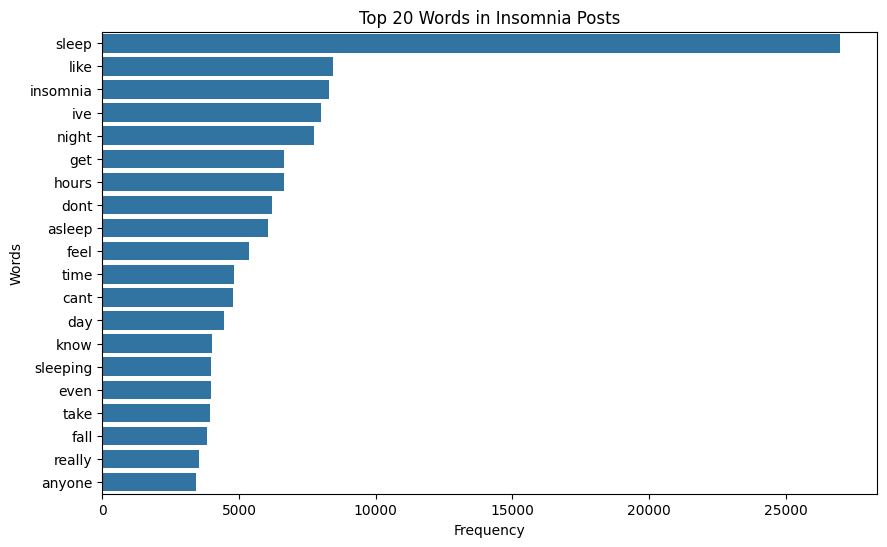

In [5]:
# Word frequencies
all_words = ' '.join(df['clean_text']).split()
word_freq = Counter(all_words)

top_words = word_freq.most_common(20)
words, counts = zip(*top_words)
plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(words))
plt.title('Top 20 Words in Insomnia Posts')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()


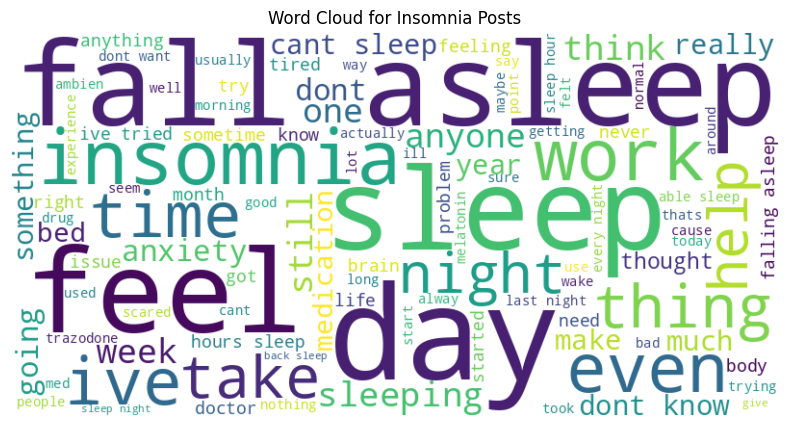

In [6]:
# Word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100, random_state=42).generate(' '.join(all_words))


plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Insomnia Posts')
plt.show()

In [7]:
# get ngrams
def get_ngrams(text, n):
    tokens = text.split()
    return list(ngrams(tokens, n))

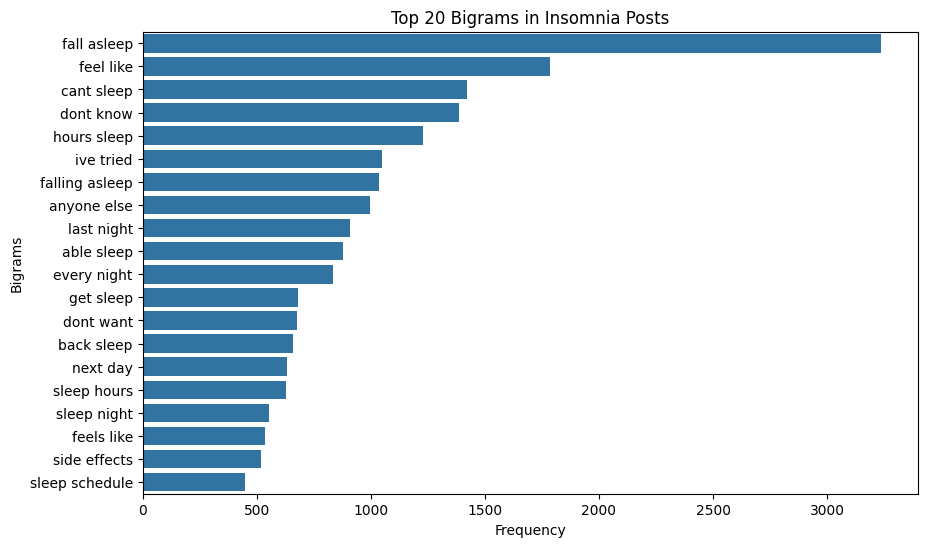

In [8]:
# Bigrams

bigrams = [bigram for text in df['clean_text'] for bigram in get_ngrams(text, 2)]
bigram_freq = Counter(bigrams)

# Bigram bar chart
top_bigrams = bigram_freq.most_common(20)
bigrams, counts = zip(*[( ' '.join(b), c) for b, c in top_bigrams])
plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(bigrams))
plt.title('Top 20 Bigrams in Insomnia Posts')
plt.xlabel('Frequency')
plt.ylabel('Bigrams')
plt.show()

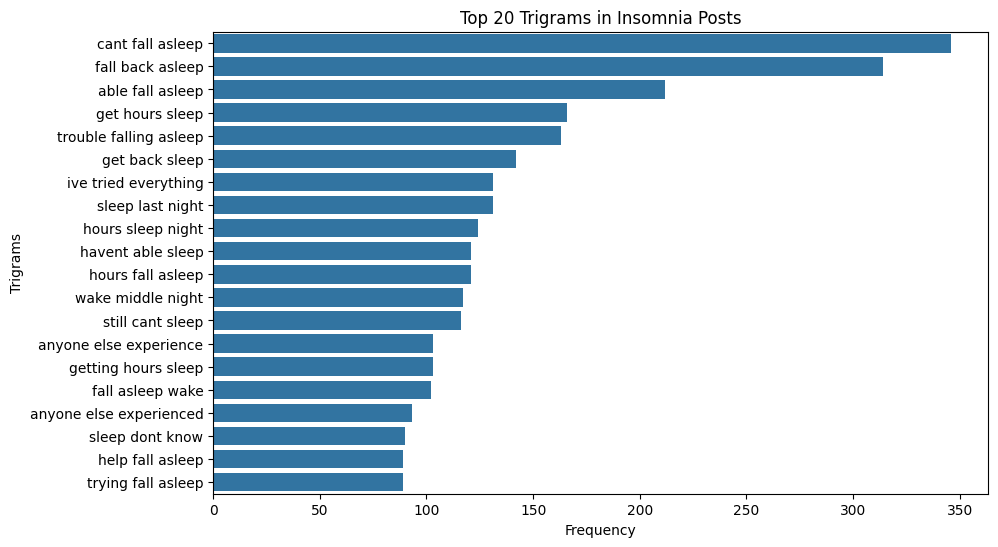

In [9]:
# Trigrams

trigrams = [trigram for text in df['clean_text'] for trigram in get_ngrams(text, 3)]
trigram_freq = Counter(trigrams)

# Trigram bar chart
top_trigrams = trigram_freq.most_common(20)
trigrams, counts = zip(*[( ' '.join(b), c) for b, c in top_trigrams])
plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(trigrams))
plt.title('Top 20 Trigrams in Insomnia Posts')
plt.xlabel('Frequency')
plt.ylabel('Trigrams')
plt.show()


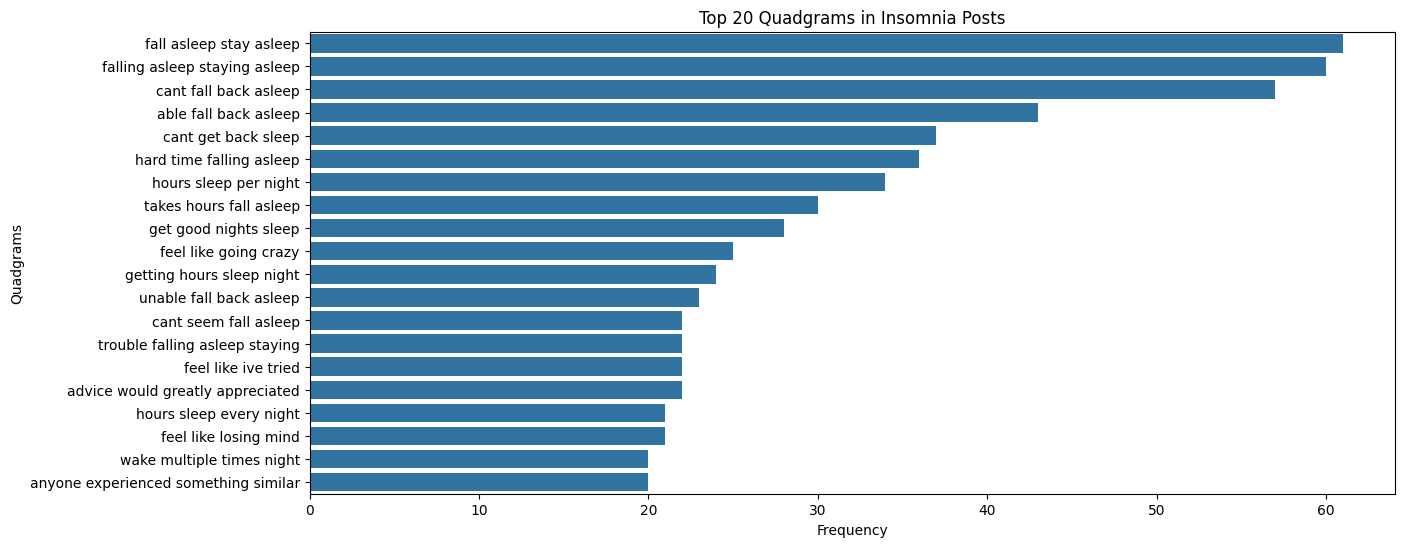

In [10]:
# Quadgrams
quadgrams = [quadgram for text in df['clean_text'] for quadgram in get_ngrams(text, 4)]
quadgram_freq = Counter(quadgrams)

# Quadgram bar chart
top_quadgrams = quadgram_freq.most_common(20)
quadgrams, counts = zip(*[(' '.join(q), c) for q, c in top_quadgrams])
plt.figure(figsize=(14, 6))
sns.barplot(x=list(counts), y=list(quadgrams))
plt.title('Top 20 Quadgrams in Insomnia Posts')
plt.xlabel('Frequency')
plt.ylabel('Quadgrams')
plt.show()

/tmp/ipython-input-4190545925.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['year_month'] = pd.to_datetime(df['created_at']).dt.to_period('M')  # CHANGED: Removed unit='s' to parse ISO 8601 format


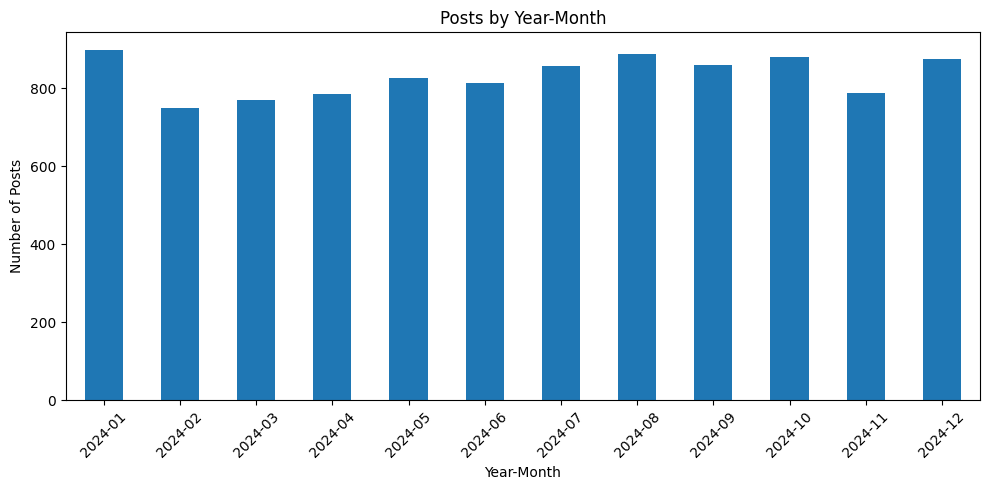

In [11]:

# Posts by year-month
df['year_month'] = pd.to_datetime(df['created_at']).dt.to_period('M')  # CHANGED: Removed unit='s' to parse ISO 8601 format
plt.figure(figsize=(10, 5))
df['year_month'].value_counts().sort_index().plot(kind='bar')
plt.title('Posts by Year-Month')
plt.xlabel('Year-Month')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

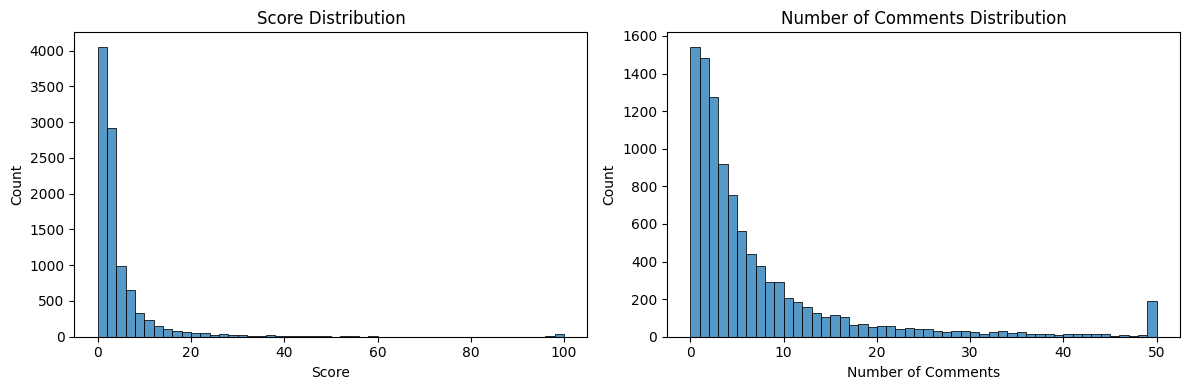

In [12]:
# Engagement distributions
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['score'].clip(upper=100), bins=50)
plt.title('Score Distribution')
plt.xlabel('Score')
plt.subplot(1, 2, 2)
sns.histplot(df['num_comments'].clip(upper=50), bins=50)
plt.title('Number of Comments Distribution')
plt.xlabel('Number of Comments')
plt.tight_layout()
plt.show()

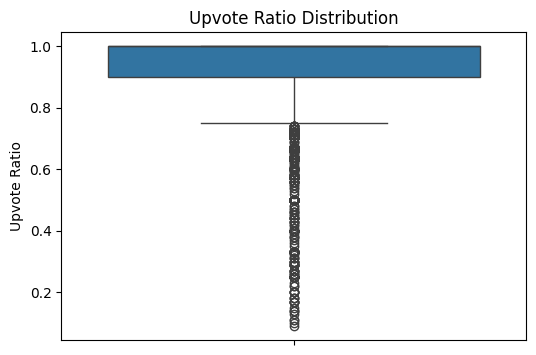

In [13]:
# Upvote ratio boxplot
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['upvote_ratio'])
plt.title('Upvote Ratio Distribution')
plt.ylabel('Upvote Ratio')
plt.show()

In [14]:
# Sentiment analysis
sid = SentimentIntensityAnalyzer()
df['sentiment'] = df['clean_text'].apply(lambda x: sid.polarity_scores(x)['compound'])
print("\nSentiment Stats:")
print(df['sentiment'].describe())



Sentiment Stats:
count    10000.000000
mean        -0.112825
std          0.701690
min         -0.998600
25%         -0.822275
50%         -0.236950
75%          0.612400
max          0.998300
Name: sentiment, dtype: float64


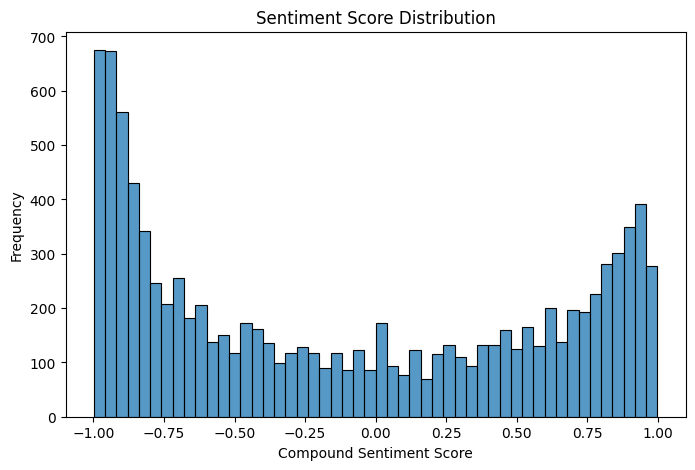

In [15]:
# Sentiment distribution

plt.figure(figsize=(8, 5))
sns.histplot(df['sentiment'], bins=50)
plt.title('Sentiment Score Distribution')
plt.xlabel('Compound Sentiment Score')
plt.ylabel('Frequency')
plt.show()


In [16]:
for col in df.columns:
    print(f"{col}: {df.iloc[0][col]}")

id: 1ha0xiz
created_at: 2024-12-09T03:46:59Z
title: Can’t get a full nights sleep and tired throughout the day
selftext: I (17f) have had troubles with sleeping since I was in middle school. No matter how many doctors I talk to or how many times I tell my parents I cannot sleep and therefore am incredibly fatigued throughout the day they don’t listen. I don’t know what to do the only advice I’ve been given is to just close my eyes but that doesn’t help. I’ve lost my appetite and I‘ve lost all interest in everything because Im too tired to do anything. Do y’all have any suggestions on what I should do?
author: Individual_Craft_514
score: 3
upvote_ratio: 1.0
num_comments: 0
over_18: False
symptom: insomnia
text: Can’t get a full nights sleep and tired throughout the day I (17f) have had troubles with sleeping since I was in middle school. No matter how many doctors I talk to or how many times I tell my parents I cannot sleep and therefore am incredibly fatigued throughout the day they do

In [17]:
# POS tagging: adjectives
def get_adjectives(text):
    tokens = word_tokenize(text)
    tagged = pos_tag(tokens)
    return [word for word, pos in tagged if pos.startswith('JJ')]
adjectives = [adj for text in df['clean_text'] for adj in get_adjectives(text)]
adj_freq = Counter(adjectives)
print("\nTop 10 Adjectives:", adj_freq.most_common(10))


Top 10 Adjectives: [('sleep', 13955), ('ive', 6509), ('cant', 2980), ('last', 2708), ('asleep', 2589), ('bad', 2064), ('able', 2056), ('good', 1689), ('dont', 1677), ('insomnia', 1645)]
